## House Price Prediction
California Housing Dataset Overview
This dataset contains information collected from the 1990 California Census. It is commonly used to practice regression problems, where the goal is to predict the median house value for a specific district (block group).

Location Features
Longitude: A measure of how far west a house is; a higher value is farther west.

Latitude: A measure of how far north a house is; a higher value is farther north.

Ocean Proximity: The ocean_proximity feature is a categorical variable that represents the location of the housing block relative to the ocean. This is often one of the most influential features in predicting house values in California.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Khám phá dữ liệu

In [27]:
df = pd.read_csv("data/housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [29]:

df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [30]:

df.isnull().sum() 

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

## Tiền xử lý dữ liệu

### Xử lý dữ liệu thiếu

In [31]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

### Loại bỏ ngoại lai

In [32]:
df = df[df['median_house_value'] < 500001]

# Với các cột dễ bị outlier (nhà/khu dân cư bất thường lớn), dùng IQR
# Không lọc median_income vì thu nhập cao vẫn là thông tin thật, hữu ích để dự đoán
for col in ['total_rooms', 'total_bedrooms', 'population', 'households']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

### Feature engineering

In [33]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

### Mã hóa dữ liệu dạng chữ

In [34]:
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

### Chuẩn hóa/giãn tỷ lệ 

In [35]:
scaler = StandardScaler()   # hoặc MinMaxScaler()
numeric_cols = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
'total_bedrooms', 'population', 'households', 'median_income','rooms_per_household', 'bedrooms_per_room', 'population_per_household']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

## Chia tập dữ liệu


In [36]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Xây dựng mô hình

In [37]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Hệ số (coefficients):", model.coef_)
print("Hệ số chặn (intercept):", model.intercept_)

Hệ số (coefficients): [-53351.87459637 -54947.53645315  11127.04743133  -4325.70081616
  16055.4044147  -37950.97808216  29579.27681935  60035.15161925
   2945.54436653   4489.85914363   -317.76664946 -35076.62537342
 154477.6641262   -9309.14386329  -1689.74345555]
Hệ số chặn (intercept): 203371.82205514068


## Đánh giá mô hình

In [38]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

MAE: 43350.68
RMSE: 58504.58
R²: 0.643


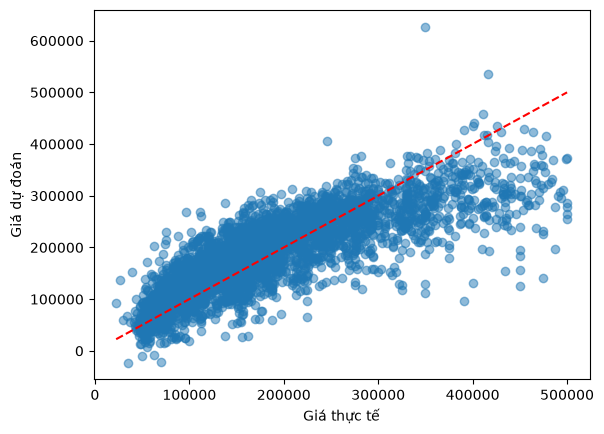

In [39]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Giá thực tế")
plt.ylabel("Giá dự đoán")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

## Tinh chỉnh mô hình

In [40]:
for alpha in [0.01, 0.1, 1, 10]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    pred = ridge.predict(X_test)
    print(f"alpha={alpha}, R²={r2_score(y_test, pred):.3f}")

alpha=0.01, R²=0.643
alpha=0.1, R²=0.643
alpha=1, R²=0.643
alpha=10, R²=0.643


## Dự đoán cho nhà mới


In [41]:
new_house = pd.DataFrame({
    'longitude': [-122.23],
    'latitude': [37.88],
    'housing_median_age': [30],
    'total_rooms': [2500],
    'total_bedrooms': [500],
    'population': [1200],
    'households': [450],
    'median_income': [5.0],
})

# Tạo tỉ lệ
new_house['rooms_per_household'] = new_house['total_rooms'] / new_house['households']
new_house['bedrooms_per_room'] = new_house['total_bedrooms'] / new_house['total_rooms']
new_house['population_per_household'] = new_house['population'] / new_house['households']

# Tạo dummy thủ công — gán 1 cho nhóm nào, 0 cho nhóm còn lại
# Ví dụ: nhà này ở gần biển (<1H OCEAN)
new_house['ocean_proximity_INLAND'] = 0
new_house['ocean_proximity_ISLAND'] = 0
new_house['ocean_proximity_NEAR BAY'] = 0
new_house['ocean_proximity_NEAR OCEAN'] = 0
# Nếu drop_first=True thì không có cột <1H OCEAN (nó là base case, giá trị 0 cho tất cả mấy cột kia)

# Chọn đúng cột, đúng thứ tự
new_house = new_house[X_train.columns]

# Scale
new_house[numeric_cols] = scaler.transform(new_house[numeric_cols])

# Dự đoán
predicted_price = model.predict(new_house)
print("Giá dự đoán:", predicted_price[0])

Giá dự đoán: 277432.6196688636
